#**Bond Price Sensitivity Analysis Using Python**

### **Project Overview**

This project analyzes the relationship between **bond prices and market yields** using Python.

A hypothetical 5-year bond with a face value of $1,000 and an 8% annual coupon rate is used to examine how changes in market yield affect its price.

### **Key Objectives**

* Calculate the price of a coupon-paying bond
* Analyze the inverse relationship between bond prices and yields
* Calculate Macaulay Duration
* Calculate Modified Duration
* Use Modified Duration to estimate price sensitivity
* Compare the estimated bond price with the actual bond price

### **CFA Relevance**

The project applies concepts from **CFA Level I Fixed Income**, particularly bond pricing, duration, and interest-rate sensitivity.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##**Define Bond**

In [ ]:
face_value = 1000
coupon_rate = 0.08
annual_coupon = face_value * coupon_rate
years_to_maturity = 5
market_yield = 0.08

##**Calculate the Bond Price**

In [ ]:

bond_price = 0

for t in range(1, years_to_maturity + 1):
    bond_price += annual_coupon / (1 + market_yield) ** t

bond_price += face_value / (1 + market_yield) ** years_to_maturity

print("Bond Price:", round(bond_price, 2))

Bond Price: 1000.0


##**Cashflow using Python**

In [ ]:
cash_flows = []

for year in range(1, years_to_maturity + 1):
    if year == years_to_maturity:
        cash_flow = annual_coupon + face_value
    else:
        cash_flow = annual_coupon

    cash_flows.append(cash_flow)

cash_flow_table = pd.DataFrame({
    "Year": range(1, years_to_maturity + 1),
    "Cash Flow": cash_flows
})

cash_flow_table

,Year,Cash Flow
0,1,80.0
1,2,80.0
2,3,80.0
3,4,80.0
4,5,1080.0


#**Let's see what happens when the market yield changes**

So far we have :

Face Value      = $1,000

Coupon Rate     = 8%

Annual Coupon   = $80

Maturity        = 5 years

Market Yield    = 8%

Bond Price      = $1,000

Now we're going to keep the **bond exactly the same** and change only the **market yield**.

## **1. Create different market yields.**

In [ ]:
yields = [0.06, 0.07, 0.08, 0.09, 0.10]

bond_prices = []

##**2. Calculate the price at each yield.**

In [ ]:
for y in yields:
    price = 0

    for t in range(1, years_to_maturity + 1):
        price += annual_coupon / (1 + y) ** t

    price += face_value / (1 + y) ** years_to_maturity

    bond_prices.append(price)

##**3. Create a Table**

In [ ]:
yield_price_table = pd.DataFrame({
    "Market Yield": [f"{y*100:.0f}%" for y in yields],
    "Bond Price": [round(price, 2) for price in bond_prices[:len(yields)]]
})

yield_price_table

,Market Yield,Bond Price
0,6%,1084.25
1,7%,1041.00
2,8%,1000.00
3,9%,961.10
4,10%,924.18


##**4. Let's Visualize it**

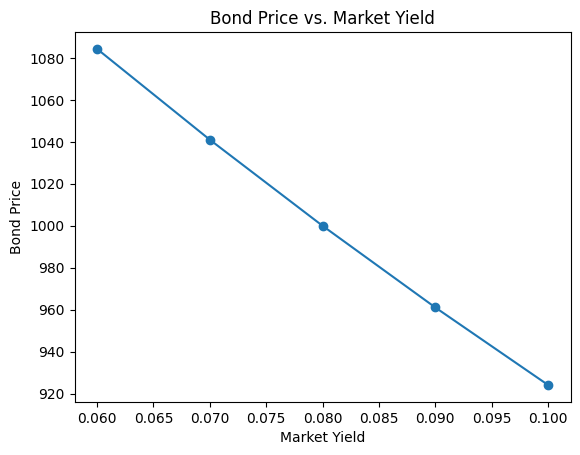

In [ ]:
plt.plot(yields, bond_prices[:len(yields)], marker="o")

plt.xlabel("Market Yield")
plt.ylabel("Bond Price")
plt.title("Bond Price vs. Market Yield")

plt.show()

## **Yield ↑ → Bond Price ↓**
## **Yield ↓ → Bond Price ↑**

##**How sensitive the bond price is to a change in yield.**

If the yield increases from **8%** to **9%**, by how much does the bond price fall?

In [ ]:
price_at_8 = bond_prices[2]
price_at_9 = bond_prices[3]

price_change = price_at_9 - price_at_8
percentage_change = (price_change / price_at_8) * 100

print("Price Change:", round(price_change, 2))
print("Percentage Price Change:", round(percentage_change, 2), "%")

Price Change: -38.9
Percentage Price Change: -3.89 %


The **negative sign** simply means the **bond's price decreased**.

This gives us the foundation for the next CFA concept: **Duration**.

##**Calculate Macaulay Duration**

First, we'll calculate the **present value of each cash flow** at the 8% market yield.

In [ ]:
present_values = []

for year, cash_flow in zip(cash_flow_table["Year"], cash_flow_table["Cash Flow"]):
    pv = cash_flow / (1 + market_yield) ** year
    present_values.append(pv)

duration_table = pd.DataFrame({
    "Year": cash_flow_table["Year"],
    "Cash Flow": cash_flow_table["Cash Flow"],
    "Present Value": present_values
})

duration_table

,Year,Cash Flow,Present Value
0,1,80.0,74.074074
1,2,80.0,68.587106
2,3,80.0,63.506579
3,4,80.0,58.802388
4,5,1080.0,735.029853


#**Calculate Macaulay Duration**

The idea is simple:

**Macaulay Duration = weighted average time until the bond's cash flows are received.**

In [ ]:
weighted_time = []

for year, pv in zip(duration_table["Year"], duration_table["Present Value"]):
    weighted_time.append(year * pv)

macaulay_duration = sum(weighted_time) / bond_price

print("Macaulay Duration:", round(macaulay_duration, 2), "years")

Macaulay Duration: 4.31 years


##**What does 4.31 years mean?**

It **doesn't mean the bond matures in 4.31 years** — it still matures in **5 years.**

It means the bond's cash flows have a **weighted average timing of about 4.31 years.**

This number will become really useful in the next step when we calculate **Modified Duration** and use it to estimate how much the bond price changes when yields move.

#**Calculate Modified Duration**

Now we take our **Macaulay Duration (4.31 years)** and convert it into **Modified Duration.**

The CFA formula is:

**Modified Duration =** **Macaulay Duration / 1 + Yield**
	​


Since our yield is **8%**,

In [ ]:
modified_duration = macaulay_duration / (1 + market_yield)

print("Modified Duration:", round(modified_duration, 2), "years")

Modified Duration: 3.99 years


##**Why do we need Modified Duration?**

This is the important part:

**Modified Duration helps us estimate the percentage change in a bond's price when its yield changes.**

The approximate relationship is:

$$ \frac{\Delta P}{P} \approx -D_{mod} \times \Delta y $$

So our next step will be to use that **3.99 years** to predict the bond's price change when yield moves from **8% → 9%**, and then compare our prediction with the **actual price change** we already calculated.



Think of the two like this:



*   **Macaulay Duration = timing measure** → tells us the weighted-average time of the bond's cash flows.
*  **Modified Duration = price-sensitivity measure** → tells us approximately how much the bond price will change when yield changes.



###**If yield changes by 1%, how much should the bond's price approximately change?**

Your Modified Duration is about **3.99**.

So if yield rises by **1%**:

                      Estimated price change ≈ −3.99 × 1% = −3.99%

 **Our actual calculation earlier showed the price went from $1,000 →
$961.10 , which is a −3.89% change.**

That's actually a nice result because we can now show:

**Modified Duration estimate: −3.99%**

**Actual price change: −3.89%**

##**Use Modified Duration to estimate the price change**

In [ ]:
yield_change = 0.01  # 8% to 9%

estimated_percentage_change = -modified_duration * yield_change

estimated_price = bond_price * (1 + estimated_percentage_change)

actual_price = price_at_9

print("Estimated Price:", round(estimated_price, 2))
print("Actual Price:", round(actual_price, 2))

Estimated Price: 960.07
Actual Price: 961.1


## **Key CFA Insight**

Bond prices and market yields have an **inverse relationship**.

When the market yield increased from **8% to 9%**, the bond price decreased from
**$1000 to $961.10**


Modified Duration was then used to estimate the price after the yield increase. The estimated price was approximately **$960.07**,  compared with the actual price of **$961.10**.

The small difference demonstrates that **Modified Duration provides an approximation of bond price sensitivity**, rather than an exact price prediction.

##**Summary Table**

In [ ]:
final_comparison = pd.DataFrame({
    "Measure": [
        "Original Bond Price",
        "Estimated Price After Yield Increase",
        "Actual Price After Yield Increase",
        "Difference"
    ],
    "Value": [
        bond_price,
        estimated_price,
        actual_price,
        abs(estimated_price - actual_price)
    ]
})

final_comparison

,Measure,Value
0,Original Bond Price,1000.000000
1,Estimated Price After Yield Increase,960.072900
2,Actual Price After Yield Increase,961.103487
3,Difference,1.030588


## **Conclusion**

This analysis demonstrates how Python can be used to apply Fixed Income concepts to a practical financial problem.

The results show that an increase in market yield leads to a decrease in bond price. Modified Duration provides a useful way to estimate the approximate impact of yield changes on bond prices.

Overall, the project connects **CFA Fixed Income concepts with Python-based financial analysis**.
